# Линейная регрессия

Задача: на основе наблюдаемых точек построить прямую, которая отображает связь между двумя и более переменными. \
Регрессия пытается подогнать функцию к наблюдаемым данным, чтобы спрогнозировать новые даные. \
Линейная регрессия пытается подогнать данные к прямой линии.

In [4]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from numpy.linalg import inv, qr

ftrs, tgt = make_regression(
    n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=15, random_state=1)

ftrs[:10]

array([[-0.61175641],
       [-0.24937038],
       [ 0.48851815],
       [ 0.76201118],
       [ 1.51981682],
       [ 0.37756379],
       [ 0.51292982],
       [-0.67124613],
       [-1.39649634],
       [ 0.31563495]])

In [34]:
tgt[:10]

array([ -53.9977391 ,  -13.0281917 ,   26.92519443,   91.19767617,
        138.91946935,   32.58496708,   35.11116131,  -32.95938308,
       -102.90734094,   24.22106871])

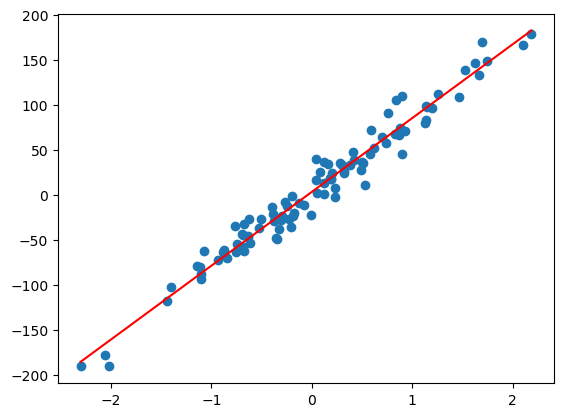

In [44]:
model = LinearRegression()
model.fit(ftrs, tgt)

x = np.linspace(ftrs.min(), ftrs.max(), 100)

plt.plot(x, model.coef_[0] * x + model.intercept_, c='r')

plt.scatter(ftrs, tgt)
plt.show()

# Простая линейная регрессия

Линейная => линейная зависимость. \
"+": 
- прогнозирование на новых данных
- анализ взаимного влияния переменных друг на друга

"-":
- точки обучаемых данных не будут точно лежать на одной прямой
- линейная регрессия не позволяет бездокозательно делать прогнозы вне диапозона имеющихся данных \
\
Данные, на основании коих разрабатывается модель - это выборка из совокупности, поэтому она должна быть репрезентативной.

**Ошибки / остатки / отклонения** - расстояние между точками данных и ближайшими по вертикали точками на прямой. \
Задача состоит в минимизации остатков. \
Обучение модели заключается в минимизации **функции потерь**.

Решения такой задачи можно разбить на 2 группы:
1) *Численные*: - проще, но требовательнее, не дает точного решения
2) *Аналитические*: - точные, но сложные.

In [8]:
#аналитическое решение
data = np.array(
    [
        [1, 5],
        [2, 7],
        [3, 7],
        [4, 10],
        [5, 11],
        [6, 14],
        [7, 17],
        [8, 19],
        [9, 22],
        [10, 28],
    ]
)

x = data[:, 0]
y = data[:, 1]

n = len(x)
w_1 = (n * np.sum(x * y) - np.sum(x) * np.sum(y)) / (n * np.sum(x ** 2) - np.sum(x) ** 2)
w_0 = (np.sum(y) / n) - (w_1 * (np.sum(x) / n))

print(w_1, w_0)

2.4 0.8000000000000007


In [72]:
#метод обратных матриц
x_1 = np.vstack([x, np.ones_like(x)]).T
w = inv(x_1.T @ x_1) @ (x_1.T @ y)
print(w)

[2.4 0.8]


In [80]:
#методом QR разложения матриц
Q, R = qr(x_1)
w = inv(R) @ Q.T @ y
print(w)

[2.4 0.8]


In [30]:
#градиентный спуск
def f(x):
    return (x - 3) ** 2 + 4

def dx_f(x):
    return 2 * x - 6

w1 = 0.0
w = 0.0

L = 0.001
iterations = 100000
x = np.random.randint(0, 5)
for i in range(iterations):
    d_x = dx_f(x)
    x -= L * d_x
print(x, f(x))

2.999999999999889 4.0
